# REPLACED BY demo_DregROM_linear_transport.py

In [2]:
#TODO: plot everything here

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
#from skimage import color, data, restoration
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
# import numpy as np
# from scipy.ndimage import gaussian_filter
# from datetime import datetime
# im_deconv = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf1.npy")
# relative_blur = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf2.npy")


# sgm = 2200/1000
# dx = 1/100
# truncate = 8
# mode = "wrap"
# t0 = datetime.now()
# blurred = gaussian_filter(
#     im_deconv, sigma=sgm/dx, truncate=truncate, mode=mode)  # + eps
# t1 = datetime.now()
# error_estimate = gaussian_filter(
#     relative_blur, sigma=sgm/dx, truncate=truncate, mode=mode)
# t2 = datetime.now()
# print((t1-t0).total_seconds())
# print((t2-t1).total_seconds())
# # ads
# # for sgm in [10, 50, 100, 500, 1000, 2000]:
# #     if sgm > 1000:
# #         truncate = 2
# #     if sgm > 100:
# #         truncate = 4
# #     dx = 1
# #     mode="wrap"
# #     t2 = datetime.now()
# #     error_estimate = gaussian_filter(
# #         relative_blur, sigma=sgm, truncate=8, mode=mode)
# #     t3 = datetime.now()
# #     print(_, np.min(relative_blur), np.max(
# #         relative_blur), (t3-t2).total_seconds())

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [4]:
m, n = 1000, 20
n_test = 11
x = np.linspace(0, 1, m, endpoint=False)
mu_train = np.linspace(0.0, 1, n, endpoint=False)[:, None]  # +1/(2*n)
#mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])[:, None]
mu_test = np.linspace(0.15, 0.2, n_test, endpoint=True)[:, None]
mu_val = x.copy()

interpolatable = (mu_train[0]<mu_val) & (mu_val<mu_train[-1])
mu_val = mu_val[interpolatable][:, None]

sigma = 0.05
num_iter1 = 10
num_iter2 = 250
mode = "constant"
rank = n
dx = 1/m
c = 2
shape = (m,)
clip = True
sigma = 0.025

In [5]:
def plot_paramspace(X, ax=None):
    if not ax:
        print("new ax")
        fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    ax.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(r"$x$")
    return ax

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\3346627305.py:6: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mu$")


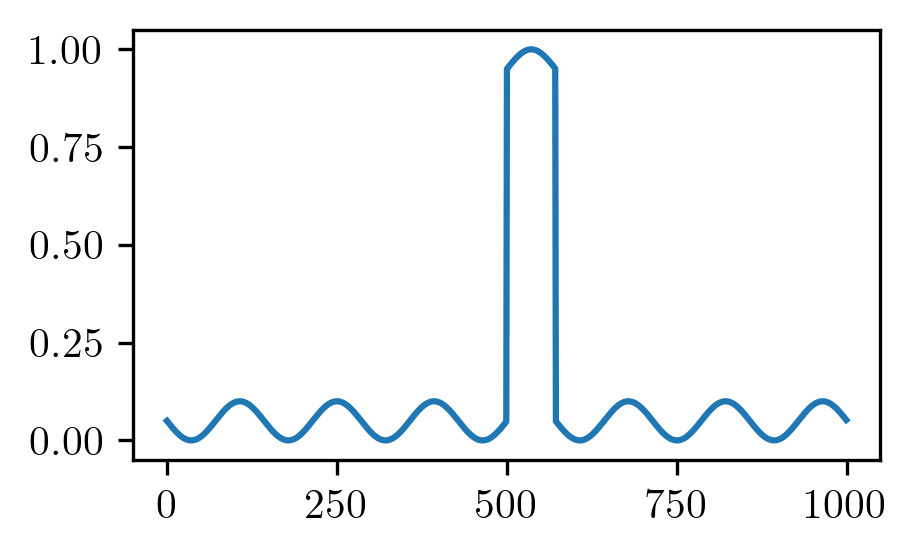

In [6]:
def pulse(x, mu, w=0.075+1e-6):
    w = 1/14
    y = np.zeros_like(x, dtype=np.float64)
    y[(0-1e-6 < (x-mu)) & ((x-mu) < w)] = 0.9
    ys = (np.sin((x-mu)*2*np.pi / w/2) + 1)/2 * 0.1
    return y+ys

plt.plot(pulse(x, .5))

In [7]:
X_train = np.empty((m, len(mu_train)))
X_test = np.zeros((m, len(mu_test)))
X_val = np.zeros((m, len(mu_val)))

for _mu, _X in zip([mu_train, mu_test, mu_val], [X_train, X_test, X_val]):
    for j, mu_j in enumerate(_mu):
        y = pulse(x, mu_j)
        _X[:, j] = y
X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma/dx, x.shape, truncate=12)
X_val_s = smoothen(X_val, sigma/dx, x.shape, truncate=12)

# Fig. 1

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2584624454.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mu$")
C:\Users\florianma\AppData\Local\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


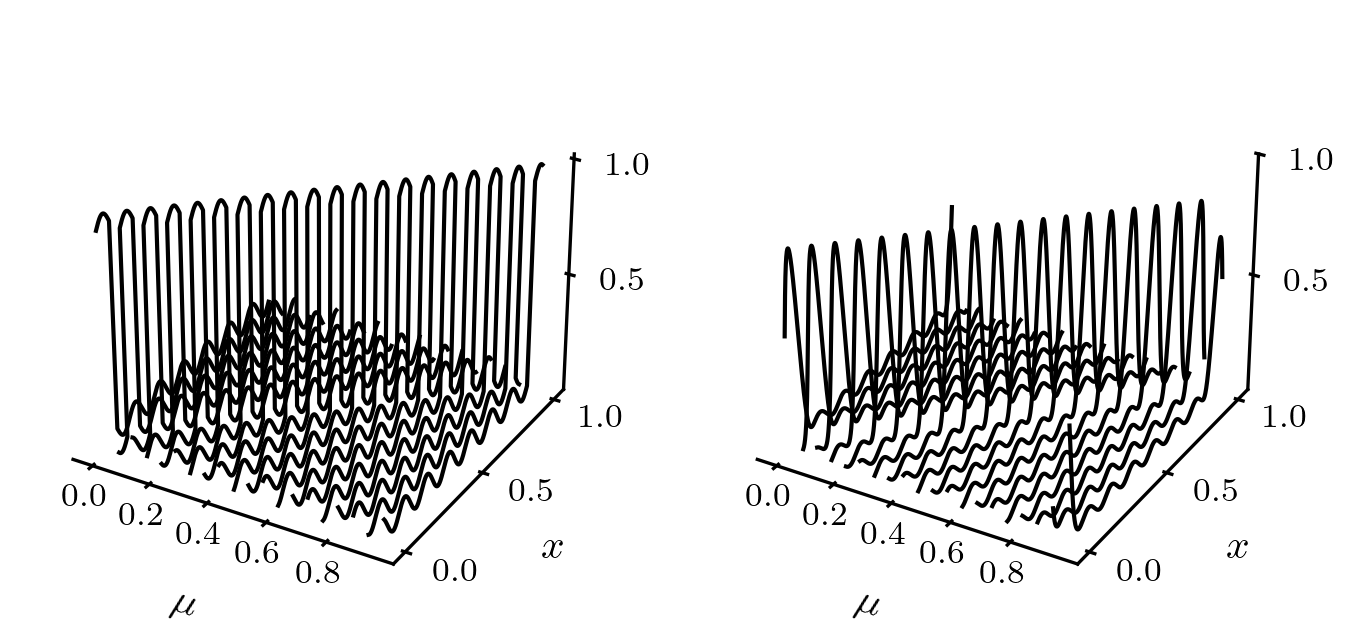

In [8]:
fig = plt.figure(figsize=(page_width_in, page_width_in/2), facecolor='white')
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(len(mu_train)):
    ax1.plot(np.ones_like(x)*mu_train[i], x, X_train[:, i], "k-", lw=1)
    ax2.plot(np.ones_like(x)*mu_train[i], x, X_train_s[:, i], "k-", lw=1)
for ax in (ax1, ax2):
    ax.xaxis.labelpad = -5
    ax.yaxis.labelpad = -5
    xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
    yticks = [0.0, 0.5, 1.0]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_zticks([0.5, 1.0])
    ax.tick_params(axis='x', which='major', pad=-5)
    ax.tick_params(axis='y', which='major', pad=-2)
    ax.tick_params(axis='z', which='major', pad=0)
    ax.set_yticklabels(yticks, va='baseline', ha='left')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        for tick in axis.get_major_ticks():
            tick.label1.set_fontsize(8)  # for some reasons it does not match
        axis.pane.set_edgecolor('white')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.xaxis.pane.fill = False  # Remove the background pane
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(r"$x$")
plt.show()


In [18]:
shape

(1000,)

In [17]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).snapshots_matrix.T
X_val_ROM = standard_rom.predict(mu_val).snapshots_matrix.T

X_train_s = smoothen(X_train, sigma/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
X_val_sROM = smooth_rom.predict(mu_val).snapshots_matrix.T

X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            shape, clip=clip, progress=False)
X_test_sROMs2 = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            shape, clip=clip, progress=False)

# pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Pulse/"
# pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
# np.save(pth+"X_test.npy", X_test)
# np.save(pth+"X_test_s.npy", X_test_s)
# np.save(pth+"X_test_ROM.npy", X_test_ROM)
# np.save(pth+"X_test_sROM.npy", X_test_sROM)

pp 0.025 2 10 (1000,) True
pp 0.025 2 250 (1000,) True


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


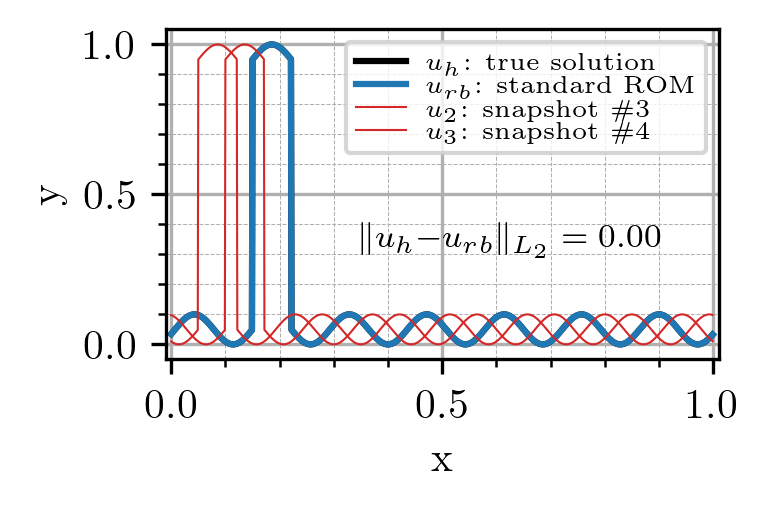

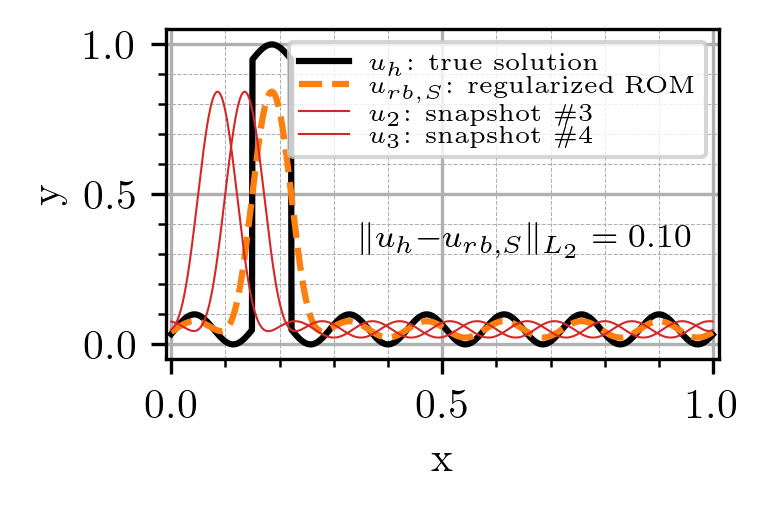

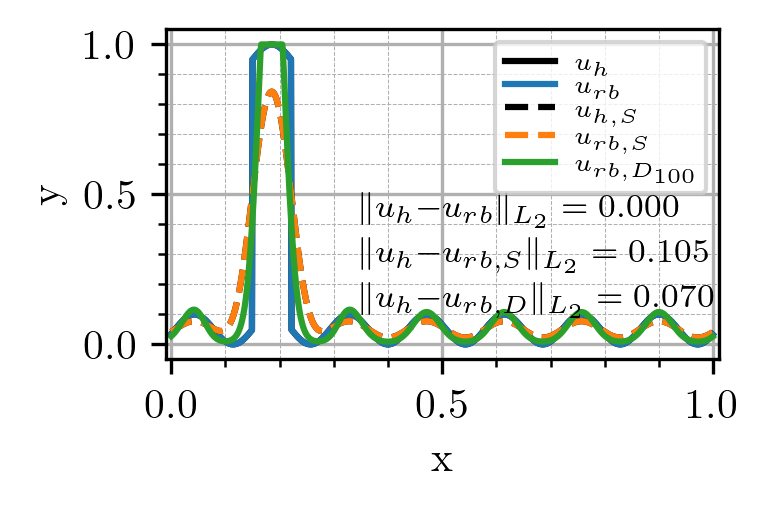

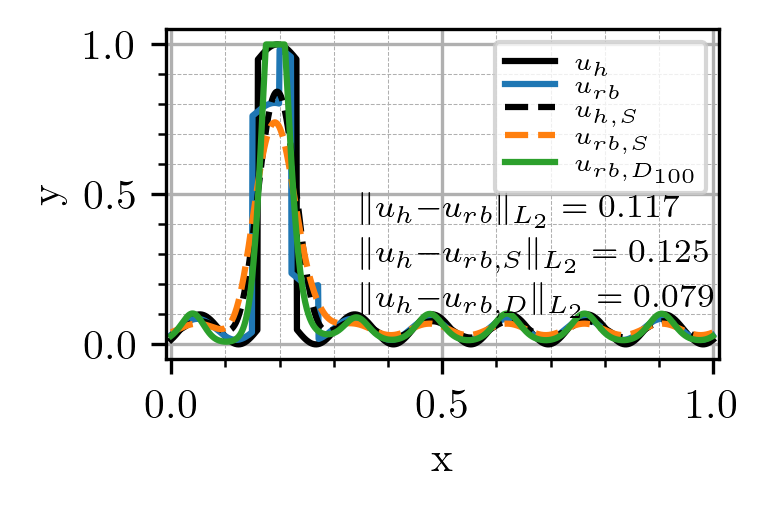

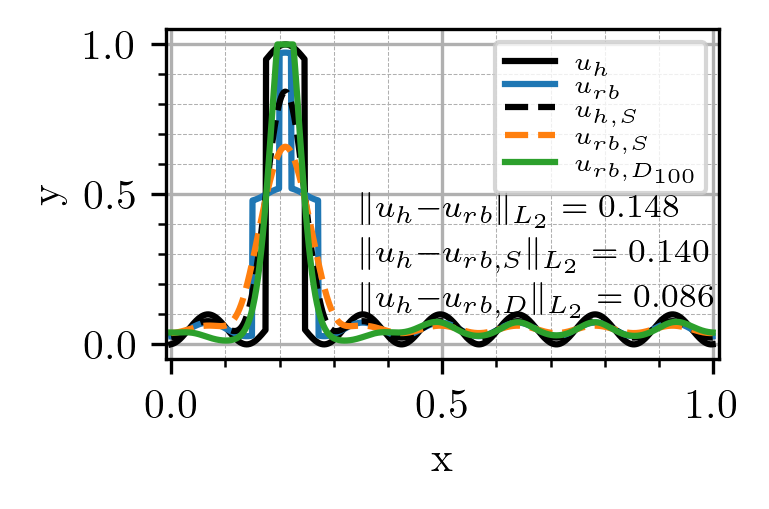

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

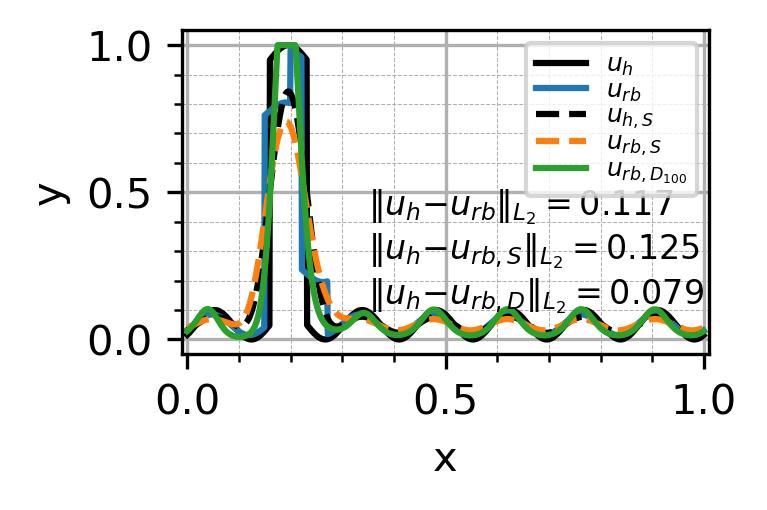

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following

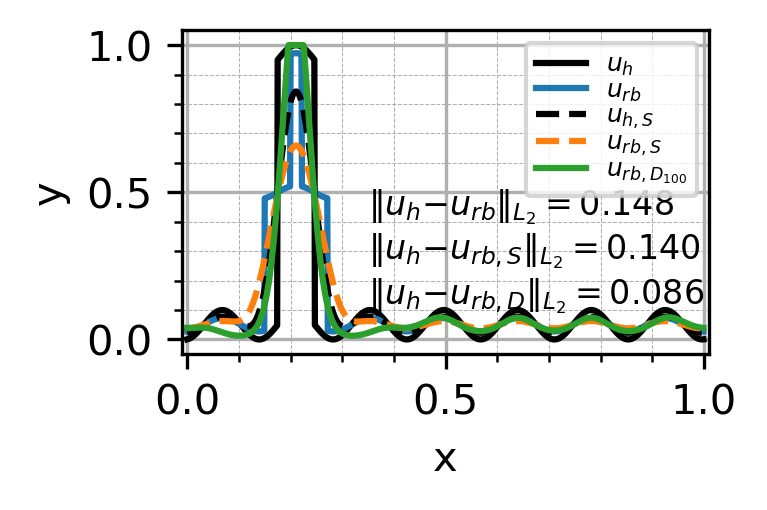

In [23]:
mu_plot = 0.2

i_c = 0  # snapshots centered between 2 training points
for _X, _X_R, lbl, col in zip([X_train, X_train_s], [X_test_ROM, X_test_sROM],
                              [r"$u_{rb}$: standard ROM", r"$u_{rb, S}$: regularized ROM"], ["C0-", "C1--"]):
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    #plt.plot(x, pulse(x, mu_plot), "kx-", ms=4, markevery=markevery, label="$u_h$: true solution")
    plt.plot(x, X_test[:, i_c], "k-", ms=4, markevery=markevery, label=r"$u_h$: true solution")
    #plt.plot(x, X_test_ROM[:, 0], "b.-", label="ROM")
    plt.plot(x, _X_R[:, i_c], col, ms=4, markevery=markevery, label=lbl)
    #plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
    #plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")
    plt.plot(x, _X[:, 1], "C3-", lw=.5, ms=4, markevery=(30, markevery), label=r"$u_{2}$: snapshot \#3")
    plt.plot(x, _X[:, 2], "C3-", lw=.5, ms=4, markevery=(30, markevery), label=r"$u_{3}$: snapshot \#4")
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    e = np.mean((X_test[:, 0]-_X_R[:, 0])**2)**.5
    ax.text(0.35, 0.35, r"$\|u_h-$"+lbl.split(":")[0]+r"$\|_{L_2}"+"={:.2f}$".format(e), fontsize=8, va="center")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

if m == 1001:
    a_list = [0, 5, 10]
else:
    a_list = [0, 2, 5]

for j in a_list:
    markevery = 45
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(x, X_test[:, j], "k-", ms=4, markevery=(0, markevery), label=r"$u_h$") # : true solution
    plt.plot(x, X_test_ROM[:, j], "C0-", ms=4, markevery=(10, markevery), label=r"$u_{rb}$") # : standard ROM
    plt.plot(x, X_test_s[:, j], "k--", ms=4, markevery=(20, markevery), label=r"$u_{h, S}$") # : regularized true solution
    plt.plot(x, X_test_sROM[:, j], "C1--", ms=4, markevery=markevery, label=r"$u_{rb, S}$") # : regularized ROM
    plt.plot(x, X_test_sROMs[:, j], "C2-", ms=4, markevery=(30, markevery), label=r"$u_{rb, D_{100}}$") # : deconvolved reg. ROM
#     plt.plot(x, X_test_sROMs2[:, j], "C3|-", ms=4, markevery=markevery, label="$u_{rb, D_{100}}$") # : deconvolved reg. ROM
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 2, 21, endpoint=True), minor=True)
    
    e = np.mean((X_test[:, j]-X_test_ROM[:, j])**2)**.5
    ax.text(0.35, 0.45, r"$\|u_h{-u_{rb}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROM[:, j])**2)**.5
    ax.text(0.35, 0.3, r"$\|u_h{-u_{rb,S}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROMs[:, j])**2)**.5
    ax.text(0.35, 0.15, r"$\|u_h{-u_{rb,D}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
#     e = np.mean((X_test[:, j]-X_test_sROMs2[:, j])**2)**.5
#     ax.text(0.35, 0.0, "$\|u_h{-u_{rb,D_{1000}}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    plt.grid(True, which='minor', linestyle='--', lw=0.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

# brute force search for c and sigma_s (all snapshots!)

In [26]:
# for snapshots in mu_test
# for sigma_s in [0.0, ..., 0.2]
# sigma_d = 2*sigma_s
# smooth rom
c = 2
sgms = np.linspace(0, 0.1, 21)
c_all = np.linspace(0, 10, 21)
eROM = L2_error(X_test_ROM, X_test)
esROM = np.zeros((n_test, 21))
esROMs = np.zeros((n_test, 21, 21))
esROMs2 = np.zeros((n_test, 21, 21))
for i, sigma_s in enumerate(sgms):
    print(sigma_s)
    X_train_s = smoothen(X_train, sigma_s/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).snapshots_matrix.T
    esROM[:, i] = L2_error(X_test_sROM, X_test)
    for j, c in enumerate(c_all):
        # de smoothing
        X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                    num_iter1, shape=shape, clip=clip)
        esROMs[:, i, j] = L2_error(X_test_sROMs, X_test)
        # de smoothing with a higher number of iterations
        X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                    num_iter2, shape=shape, clip=clip)
        esROMs2[:, i, j] = L2_error(X_test_sROMs2, X_test)


# me = 5
# for p in range(n_test):
#     print(mu_test[p])
#     fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
#     plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
#     plt.plot(sgms, esROM[p, :], "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
#     plt.plot(sgms, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
#     plt.plot(sgms, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
#     plt.legend()
#     plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
#     plt.xlabel("$\sigma_S$")
#     plt.xlim(0, .1)
#     plt.ylim(0, 0.4)
#     ax.set_xticks(np.linspace(0, .1, 21, endpoint=True), minor=True)
#     ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
#     plt.grid(True, which='minor', linestyle='--', lw=.25)
#     plt.grid(True, which='major', linestyle='-')
#     plt.show()

0.0
pp 0.0 0.0 10 (1000,) True
pp 0.0 0.0 250 (1000,) True
pp 0.0 0.5 10 (1000,) True
pp 0.0 0.5 250 (1000,) True
pp 0.0 1.0 10 (1000,) True
pp 0.0 1.0 250 (1000,) True
pp 0.0 1.5 10 (1000,) True
pp 0.0 1.5 250 (1000,) True
pp 0.0 2.0 10 (1000,) True
pp 0.0 2.0 250 (1000,) True
pp 0.0 2.5 10 (1000,) True
pp 0.0 2.5 250 (1000,) True
pp 0.0 3.0 10 (1000,) True
pp 0.0 3.0 250 (1000,) True
pp 0.0 3.5 10 (1000,) True
pp 0.0 3.5 250 (1000,) True
pp 0.0 4.0 10 (1000,) True
pp 0.0 4.0 250 (1000,) True
pp 0.0 4.5 10 (1000,) True
pp 0.0 4.5 250 (1000,) True
pp 0.0 5.0 10 (1000,) True
pp 0.0 5.0 250 (1000,) True
pp 0.0 5.5 10 (1000,) True
pp 0.0 5.5 250 (1000,) True
pp 0.0 6.0 10 (1000,) True
pp 0.0 6.0 250 (1000,) True
pp 0.0 6.5 10 (1000,) True
pp 0.0 6.5 250 (1000,) True
pp 0.0 7.0 10 (1000,) True
pp 0.0 7.0 250 (1000,) True
pp 0.0 7.5 10 (1000,) True
pp 0.0 7.5 250 (1000,) True
pp 0.0 8.0 10 (1000,) True
pp 0.0 8.0 250 (1000,) True
pp 0.0 8.5 10 (1000,) True
pp 0.0 8.5 250 (1000,) True
pp 0.0

-48.347949104733424 %


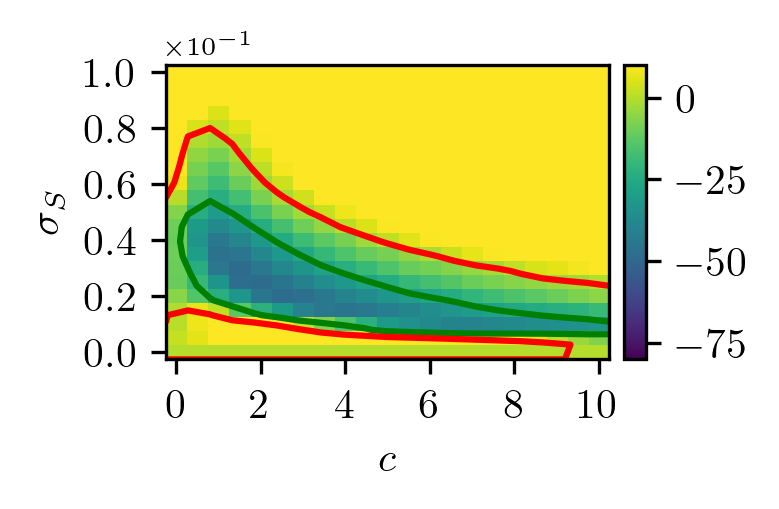

0.10113252876993463
0.12220655505566301
5 4 0.025 2.0


In [28]:
sigmas = sgms
mean_eROM = np.mean(eROM)
mean_esROM = np.mean(esROM, axis=0)
mean_esROMs = np.mean(esROMs2, axis=0)

# print(mean_eROM)
# print(np.min(mean_esROM), np.max(mean_esROM))
# print(np.min(mean_esROMs), np.max(mean_esROMs))
# print(np.min(mean_esROMs)/mean_eROM)
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
dc = c_all[1]-c_all[0]
ds = sigmas[1]-sigmas[0]
ext = (c_all[0]-dc/2, c_all[-1]+dc/2, (sigmas[0]-ds/2), (sigmas[-1]+ds/2))
Z = mean_esROMs/mean_eROM*100-100
print(np.min(Z), "%")
cs = ax.imshow(Z, interpolation="nearest", origin="lower", vmin=-80, vmax=10, extent=ext)
contours = ax.contour(Z, levels=[-75, -50, -25, 0], colors=["g", "g", "g", "r"], extent=ext)
#     cs.cmap.set_over('red')
#     cs.cmap.set_under('blue')
#np.save(pth+"mean_esROMs.npy", mean_esROMs)
ax.set_xticks(c_all[::4])
ax.set_yticks(sigmas[::4])
ax.set_xlabel("$c$")
ax.set_ylabel(r"$\sigma_S$")
ax.set_aspect("auto")
#     ax.ticklabel_format(axis='y', style='sci', useOffset=True)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useOffset=False, useMathText=True)
ax.yaxis.get_offset_text().set_size(6)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(cs, cax=cax)
cbar.set_ticks([-75, -50, -25, 0])
#plt.savefig(pth+"2nd_ex_hyperparams.pdf")
plt.show()
print(np.min(mean_esROMs[0, :]))
print(np.min(mean_esROMs[-1, :]))
i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
print(i, j, sigmas[i], c_all[j])
sigma, c = sigmas[i], c_all[j]

# brute force search for c (per snapshot!)

In [29]:
# # for snapshots in mu_test
# # for sigma_s in [0.0, ..., 0.2]
# # sigma_d = 2*sigma_s
# # smooth rom
# sigma_s = 0.05
# cs = np.linspace(0, 10, 21)
# eROM = L2_error(X_test_ROM, X_test)
# esROMs = np.zeros((n_test, 21))
# esROMs2 = np.zeros((n_test, 21))

# X_train_s = smoothen(X_train, sigma_s/dx, shape)
# smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
# X_test_sROM = smooth_rom.predict(mu_test).T
# esROM = L2_error(X_test_sROM, X_test)
# for i, c in enumerate(cs):
#     print(c)
#     # de smoothing
#     X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
#                                 num_iter1, shape=shape, clip=clip)
#     esROMs[:, i] = L2_error(X_test_sROMs, X_test)
#     # de smoothing with a higher number of iterations
#     X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
#                                 num_iter2, shape=shape, clip=clip)
#     esROMs2[:, i] = L2_error(X_test_sROMs2, X_test)

    
# me = 5
# for p in range(n_test):
#     print(mu_test[p])
#     fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
#     plt.plot(cs, np.full(cs.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
#     plt.plot(cs, np.full(cs.shape, esROM[p]), "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
#     plt.plot(cs, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
#     plt.plot(cs, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
#     plt.legend()
#     plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
#     plt.xlabel("$c$")
#     plt.xlim(0, .1)
#     plt.ylim(0, 0.4)
#     ax.set_xticks(np.linspace(0, 10, 21, endpoint=True), minor=True)
#     ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
#     plt.grid(True, which='minor', linestyle='--', lw=.25)
#     plt.grid(True, which='major', linestyle='-')
#     plt.show()

<>:45: SyntaxWarning: invalid escape sequence '\|'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\|'
<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\s'
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2102871954.py:45: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2102871954.py:46: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma_D$")
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2102871954.py:73: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\

0 [0.001] 8 0.04 0.06598038145221072
1 [0.002] 8 0.04 0.06682115738544914
2 [0.003] 8 0.04 0.06777274842164163
3 [0.004] 8 0.04 0.06882678072322233
4 [0.005] 8 0.04 0.06996397038833316
5 [0.006] 8 0.04 0.07117371476358515
6 [0.007] 8 0.04 0.07242692115953728
7 [0.008] 8 0.04 0.07370207458129302
8 [0.009] 9 0.045 0.07496501783485036
9 [0.01] 9 0.045 0.07613875364052339
10 [0.011] 9 0.045 0.07727781146197209
11 [0.012] 9 0.045 0.07837840393504272
12 [0.013] 9 0.045 0.07942494021697886
13 [0.014] 9 0.045 0.08041190939529294
14 [0.015] 9 0.045 0.08132973737653242
15 [0.016] 9 0.045 0.08217366189814726
16 [0.017] 9 0.045 0.08293851931517947
17 [0.018] 9 0.045 0.08361714175395552
18 [0.019] 9 0.045 0.08421004514360571
19 [0.02] 9 0.045 0.08471372200125503
20 [0.021] 9 0.045 0.08512711671315083
21 [0.022] 9 0.045 0.08544973431476052
22 [0.023] 9 0.045 0.08567792867970685
23 [0.024] 9 0.045 0.0858160030098198
24 [0.025] 9 0.045 0.08585985192005881
25 [0.026] 9 0.045 0.08581401405669396
26 [0.0

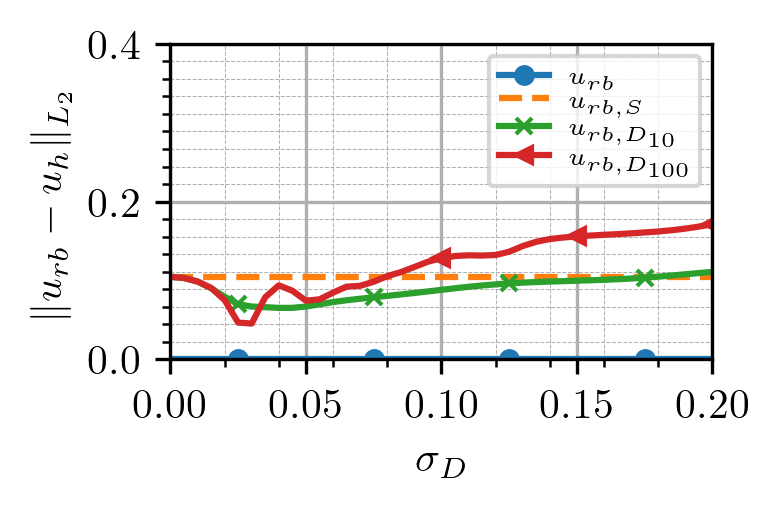

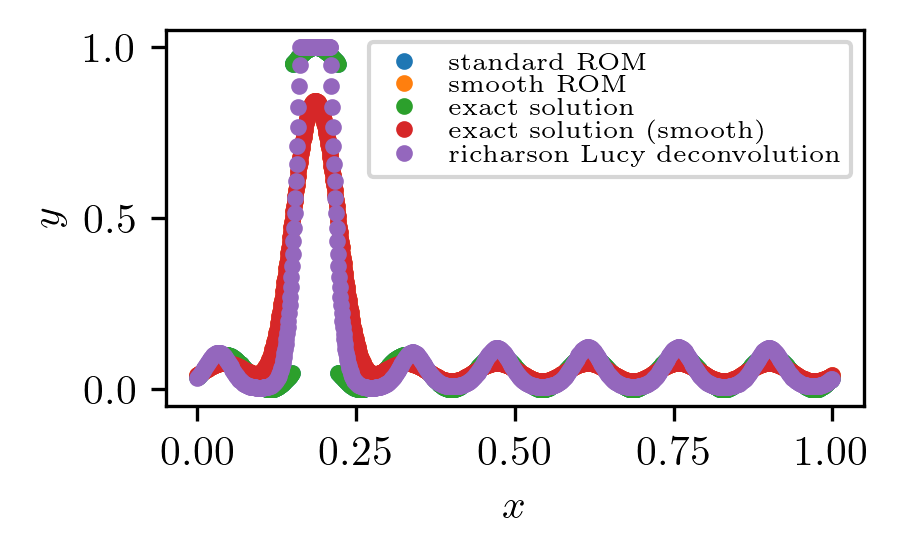

150 [0.151] 8 0.04 0.06598038145221065
151 [0.152] 8 0.04 0.06682115738544907
152 [0.153] 8 0.04 0.06777274842164159
153 [0.154] 8 0.04 0.06882678072322228
154 [0.155] 8 0.04 0.06996397038833312
155 [0.156] 8 0.04 0.07117371476358512
156 [0.157] 8 0.04 0.07242692115953724
157 [0.158] 8 0.04 0.07370207458129299
158 [0.159] 9 0.045 0.07496501783485034
159 [0.16] 9 0.045 0.07613875364052339
160 [0.161] 9 0.045 0.07727781146197206
161 [0.162] 9 0.045 0.07837840393504272
162 [0.163] 9 0.045 0.07942494021697885
163 [0.164] 9 0.045 0.08041190939529294
164 [0.165] 9 0.045 0.08132973737653242
165 [0.166] 9 0.045 0.08217366189814722
166 [0.167] 9 0.045 0.08293851931517945
167 [0.168] 9 0.045 0.0836171417539555
168 [0.169] 9 0.045 0.0842100451436057
169 [0.17] 9 0.045 0.08471372200125504
170 [0.171] 9 0.045 0.08512711671315082
171 [0.172] 9 0.045 0.0854497343147605
172 [0.173] 9 0.045 0.08567792867970683
173 [0.174] 9 0.045 0.08581600300981976
174 [0.175] 9 0.045 0.08585985192005878


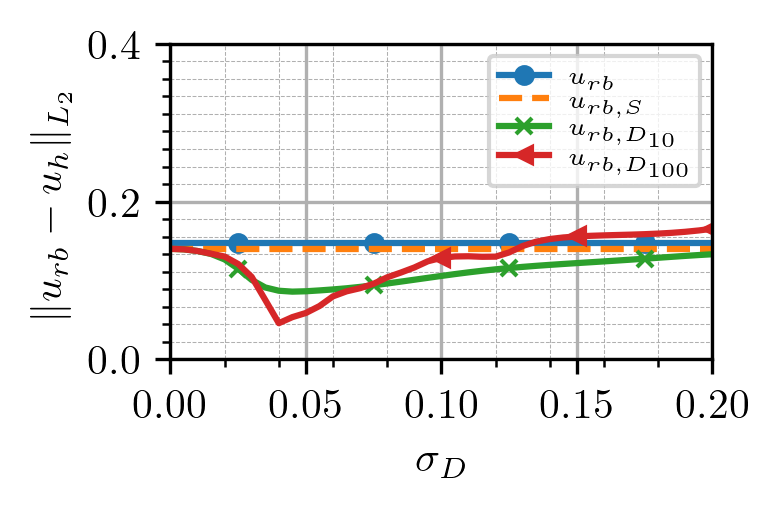

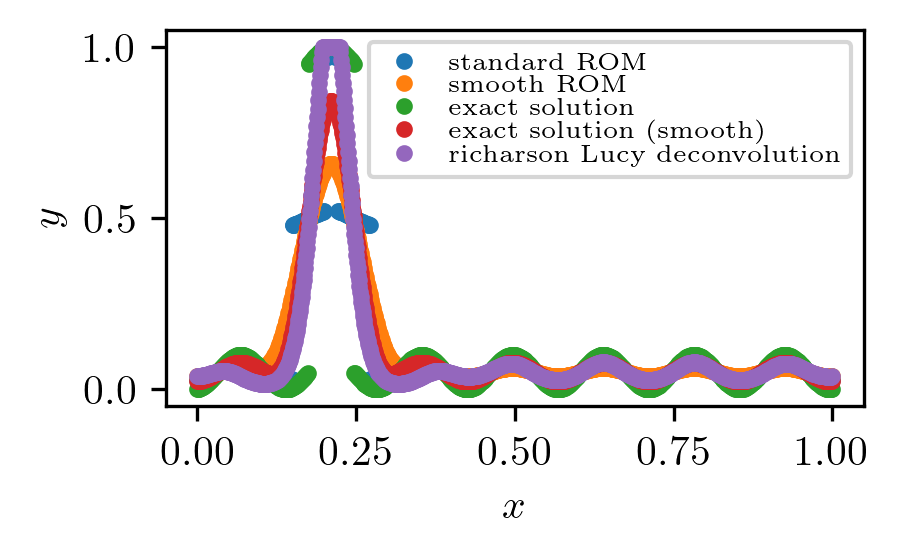

175 [0.176] 9 0.045 0.08581401405669392
176 [0.177] 9 0.045 0.08567413019635378
177 [0.178] 9 0.045 0.08544415193205804
178 [0.179] 9 0.045 0.08511964948329187
179 [0.18] 9 0.045 0.08470443254007232
180 [0.181] 9 0.045 0.08419909815028476
181 [0.182] 9 0.045 0.08360456168438932
182 [0.183] 9 0.045 0.08292452024082968
183 [0.184] 9 0.045 0.08215815563784208
184 [0.185] 9 0.045 0.08131297106635696
185 [0.186] 9 0.045 0.08039408204993838
186 [0.187] 9 0.045 0.07940599001313246
187 [0.188] 9 0.045 0.07835862991093273
188 [0.189] 9 0.045 0.07725756426310042
189 [0.19] 9 0.045 0.07611799539681133
190 [0.191] 9 0.045 0.07494407042859828
191 [0.192] 8 0.04 0.07369074304251587
192 [0.193] 8 0.04 0.0724151785674139
193 [0.194] 8 0.04 0.07116149155492703
194 [0.195] 8 0.04 0.06995285875460465
195 [0.196] 8 0.04 0.06881730921067075
196 [0.197] 8 0.04 0.06776444191638177
197 [0.198] 8 0.04 0.0668141574247735
198 [0.199] 8 0.04 0.06597613536490528
199 [0.2] 8 0.04 0.06528395493548335


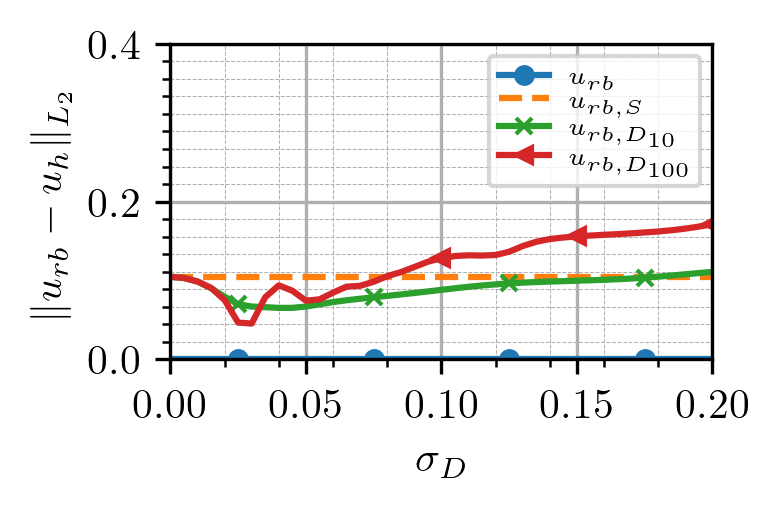

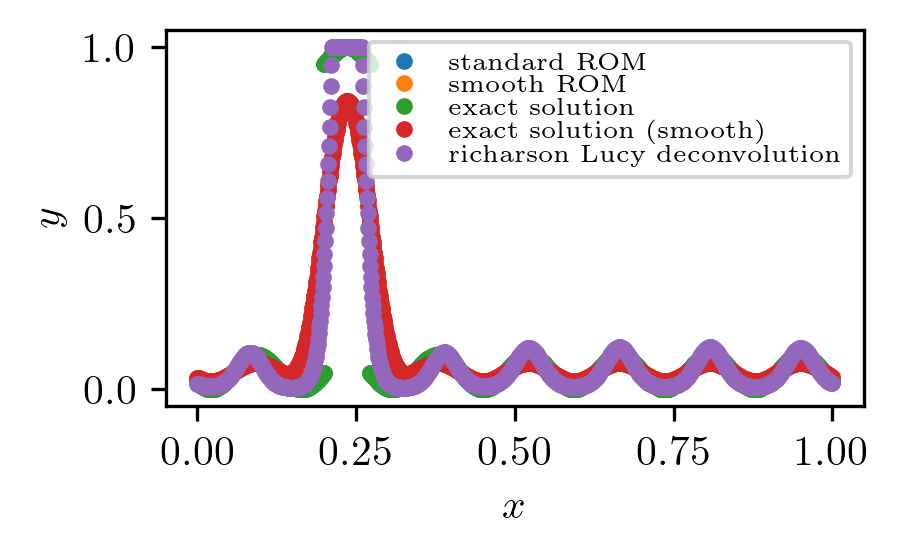

200 [0.201] 8 0.04 0.06598038145221065
201 [0.202] 8 0.04 0.06682115738544908
202 [0.203] 8 0.04 0.0677727484216416
203 [0.204] 8 0.04 0.06882678072322232
204 [0.205] 8 0.04 0.06996397038833313
205 [0.206] 8 0.04 0.07117371476358512
206 [0.207] 8 0.04 0.07242692115953724
207 [0.208] 8 0.04 0.07370207458129299
208 [0.209] 9 0.045 0.07496501783485036
209 [0.21] 9 0.045 0.07613875364052342
210 [0.211] 9 0.045 0.0772778114619721
211 [0.212] 9 0.045 0.07837840393504275
212 [0.213] 9 0.045 0.0794249402169789
213 [0.214] 9 0.045 0.08041190939529297
214 [0.215] 9 0.045 0.08132973737653243
215 [0.216] 9 0.045 0.08217366189814726
216 [0.217] 9 0.045 0.08293851931517948
217 [0.218] 9 0.045 0.0836171417539555
218 [0.219] 9 0.045 0.08421004514360571
219 [0.22] 9 0.045 0.08471372200125507
220 [0.221] 9 0.045 0.08512711671315086
221 [0.222] 9 0.045 0.08544973431476052
222 [0.223] 9 0.045 0.08567792867970685
223 [0.224] 9 0.045 0.0858160030098198
224 [0.225] 9 0.045 0.08585985192005881
225 [0.226] 9 0

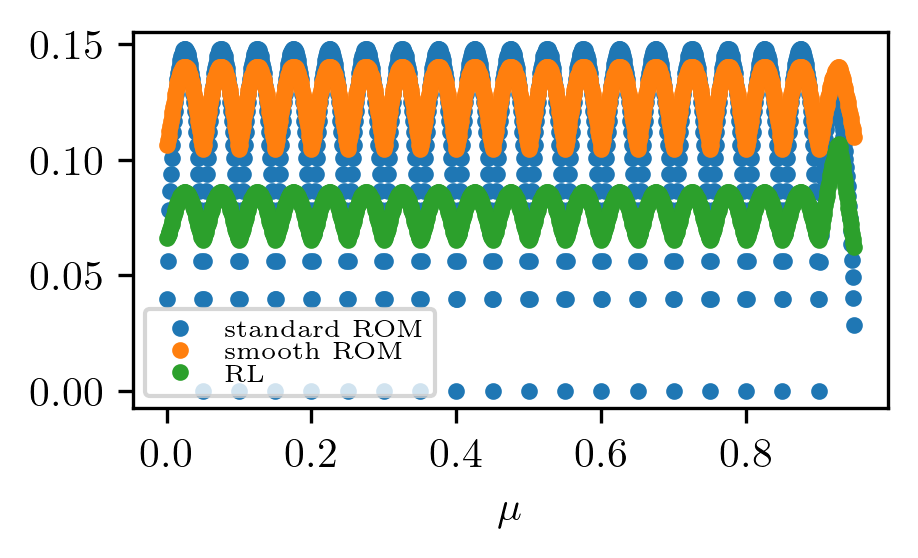

4817512775646.502


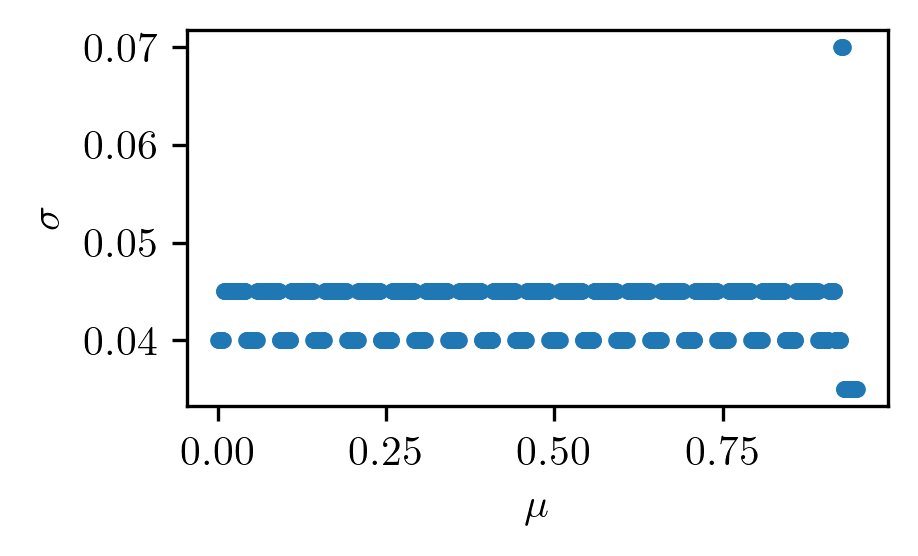

In [32]:
bf = True
if bf:
    n_s = 41
    sgms = np.linspace(0.0, 0.2, n_s)
    e1 = np.zeros((len(mu_val), n_s),)-1
    e2 = np.zeros((len(mu_val), n_s),)-1

    esROM = np.empty(len(mu_val), )
    eROM = np.empty(len(mu_val), )
    esROMs = np.empty(len(mu_val), )
    sgm_opt = np.empty(len(mu_val), )

    for p in range(len(mu_val)):
#         if np.round(mu_val[p], decimals=3) not in mu_test:
#             continue
        exact = X_val[:, p]
        standard_ROM = X_val_ROM[:, p]
        blurred = np.copy(X_val_sROM[:, p])
        esROM[p] = np.mean((blurred-X_val[:, p])**2)**.5
        eROM[p] = np.mean((standard_ROM-X_val[:, p])**2)**.5


        for i, sgm in enumerate(sgms):
            deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter1, damping=2, clip=clip)
            e1[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5

        ind = np.argmin(e1[p])
        sgm_opt[p] = sgms[ind]
        esROMs[p] = e1[p, ind]

        print(p, mu_val[p], ind, sgm_opt[p], e1[p, ind])

        if np.round(mu_val[p], decimals=3) in [0.15, 0.175, 0.2]:
            for i, sgm in enumerate(sgms):
                deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter2, damping=2, clip=clip)
                e2[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5
            
            me = 10
            fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
            plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(5, me), label=r"$u_{rb}$")
            plt.plot(sgms, np.full(sgms.shape, esROM[p]), "C1--", ms=4, markevery=me, label=r"$u_{rb,S}$")
            plt.plot(sgms, e1[p], "C2x-", ms=4, markevery=(5, me), label=r"$u_{rb,D_{10}}$")
            plt.plot(sgms, e2[p], "C3<-", ms=4, markevery=(20, me), label=r"$u_{rb,D_{100}}$")
            plt.legend()
            plt.ylabel(r"$\|u_{rb}-u_h\|_{L_2}$")
            plt.xlabel(r"$\sigma_D$")
            plt.xlim(0, .2)
            plt.ylim(0, 0.4)
            plt.legend()
            ax.set_xticks(np.linspace(0, .2, 11, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
            plt.grid(True, which='minor', linestyle='--', lw=.25)
            plt.grid(True, which='major', linestyle='-')
            plt.show()

            deconvolved_RL = richardson_lucy(x, blurred, sgm_opt[p], num_iter=num_iter1, damping=2, clip=clip)

            plt.plot(x, standard_ROM, "C0.", label="standard ROM")
            plt.plot(x, blurred, "C1.", label="smooth ROM")
            plt.plot(x, X_val[:, p], "C2.", label="exact solution")
            plt.plot(x, X_val_s[:, p], "C3.", label="exact solution (smooth)")
            plt.plot(x, deconvolved_RL, "C4.", label="richarson Lucy deconvolution")
            plt.legend()
            plt.xlabel("$x$")
            plt.ylabel("$y$")
            plt.show()


    plt.plot(mu_val, eROM, "C0.", label="standard ROM")
    plt.plot(mu_val, esROM, "C1.", label="smooth ROM")
    plt.plot(mu_val, esROMs, "C2.", label="RL")
    plt.xlabel("error")
    plt.xlabel(r"$\mu$")
    plt.legend()
    plt.show()

    print(np.mean(esROM/eROM))
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.xlabel(r"$\mu$")
    plt.ylabel(r"$\sigma$")
    plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\3145388113.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")


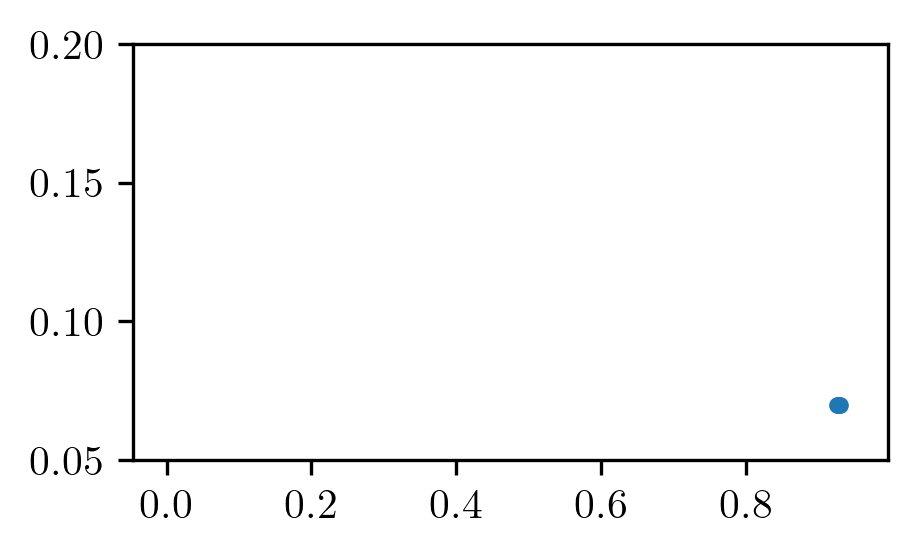

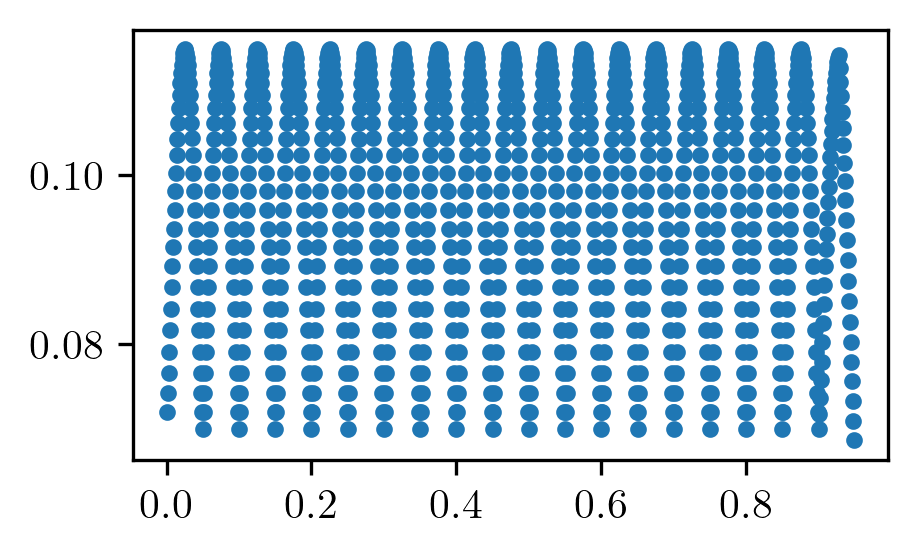

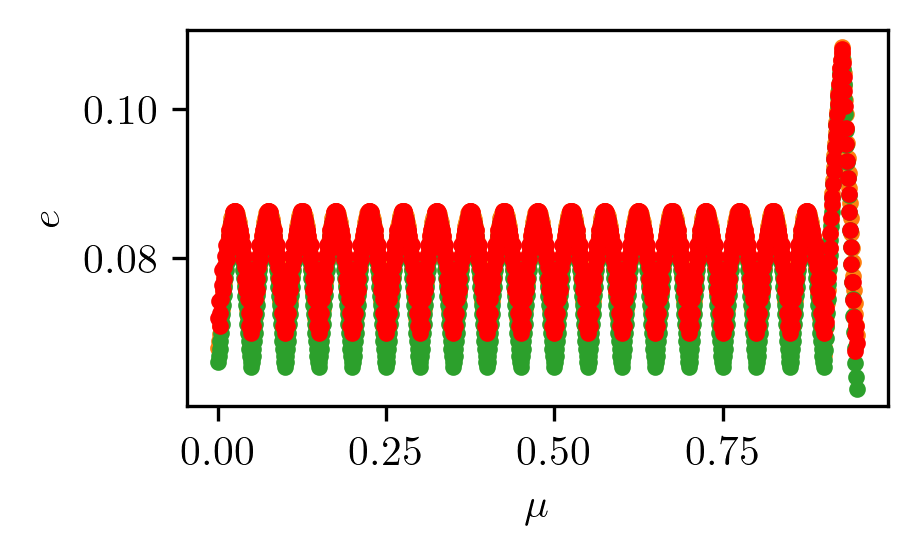

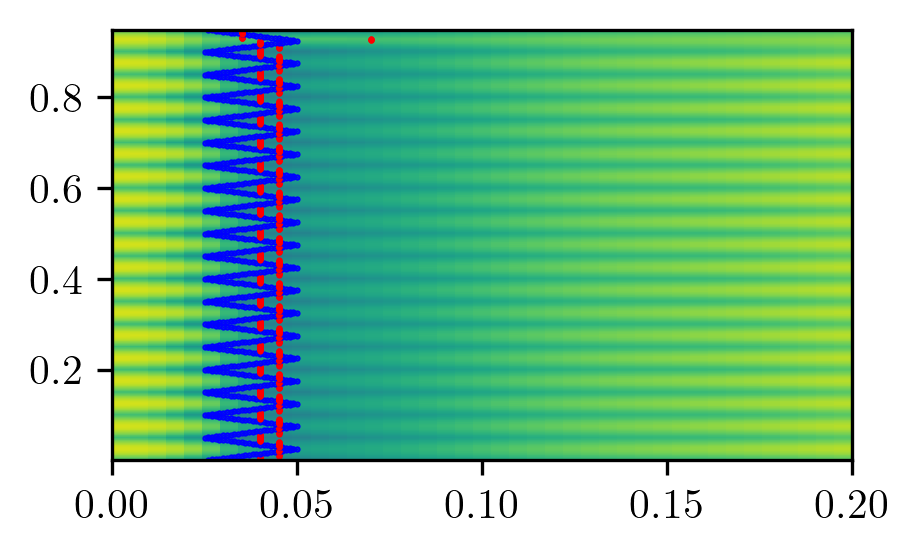

In [33]:
if bf:
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.ylim(0.05, 0.2)
    plt.show()

    ind = np.argmin(np.abs(sgms-sigma))
    plt.plot(mu_val, e1[:, ind], "C0.")

    ind = np.argmin(np.abs(sgms-2*sigma))
    fig, ax = plt.subplots()
    plt.plot(mu_val, e1[:, ind], "C1.")
    plt.plot(mu_val, np.min(e1, axis=1), "C2.")
    #plt.xlim(0.2, 0.5)
    #plt.ylim(1.8, 2.0)
    plt.xlabel("$\mu$")
    plt.ylabel("$e$")
    left, right, bottom, top = sgms[0], sgms[-1], mu_val[0, 0], mu_val[-1, 0]

    fig, ax2 = plt.subplots()
    plt.imshow(e1, vmin=0.0, vmax=0.15, extent=(left, right, bottom, top), origin="lower", interpolation="nearest")  # 
    plt.gca().set_aspect("auto")
    for p, _mu in enumerate(mu_val):
        d = np.min(np.abs(_mu-mu_train))
        ind2 = np.argmin(np.abs(sgms - (sigma+1*d)))

        ax.plot(_mu, e1[p, ind2], "r.")
        plt.plot(sigma+1*d, _mu, "b.", ms=1)

        ind = np.argmin(e1[p, :])
        plt.plot(sgms[ind], _mu, "r.", ms=1)
    plt.show()

# truncation leads to bad results

pp 0.05 2.0 250 (1000,) True
0.05000000, 2.00000000, 0, 0.10113253, 0.17051587, 0.08527193, -15.6830 %
3.357312197434884e-16 0.16474875287493734 0.07265228819254924


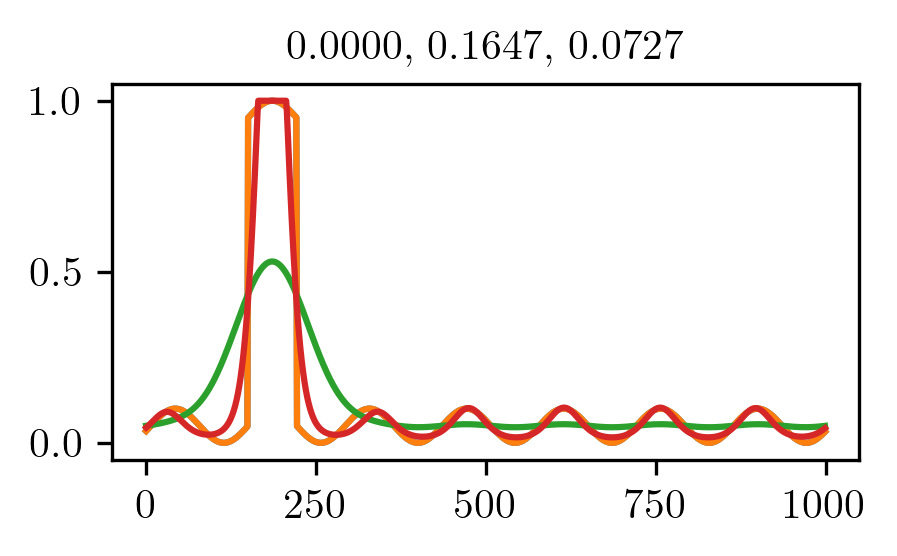

0.08653063549174125 0.1678924703611124 0.06429239527806861


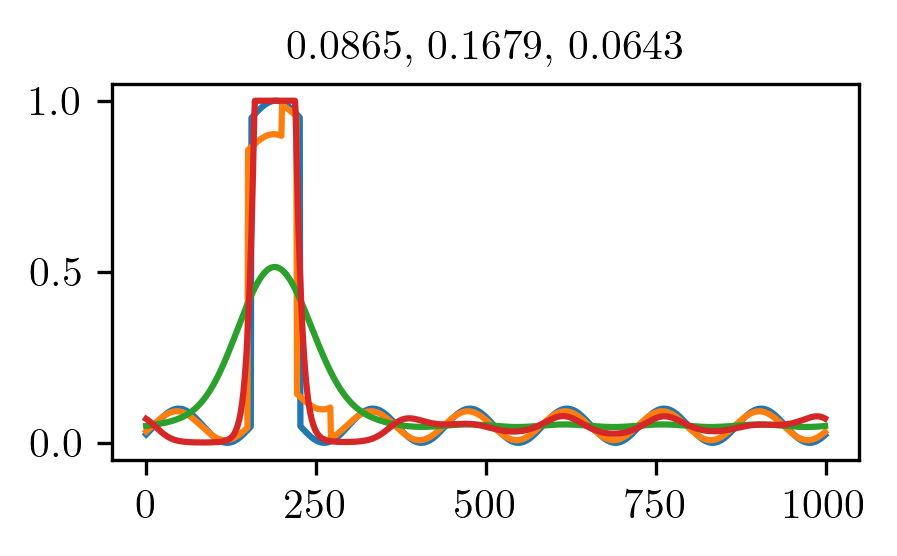

0.11660394649347222 0.17068945548490122 0.07210201109011369


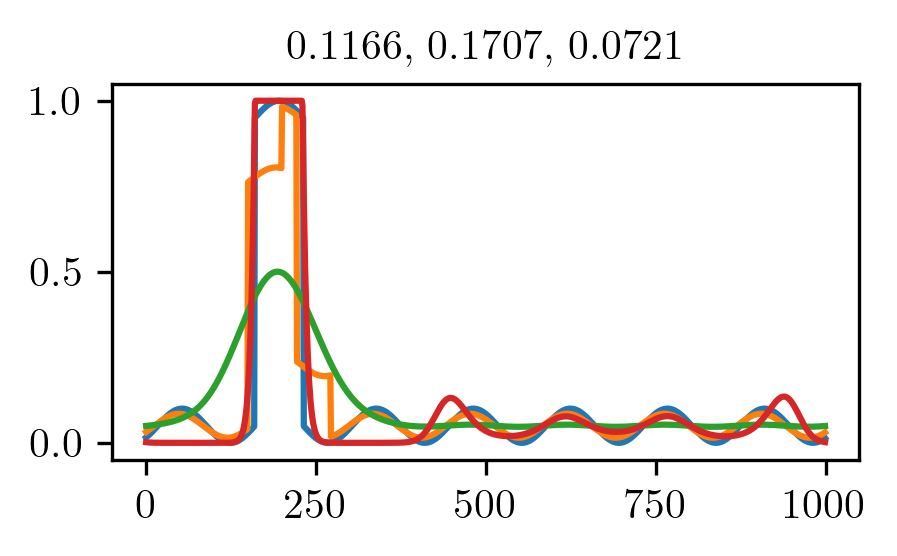

0.13461638691003935 0.1728756121544521 0.09082447739691758


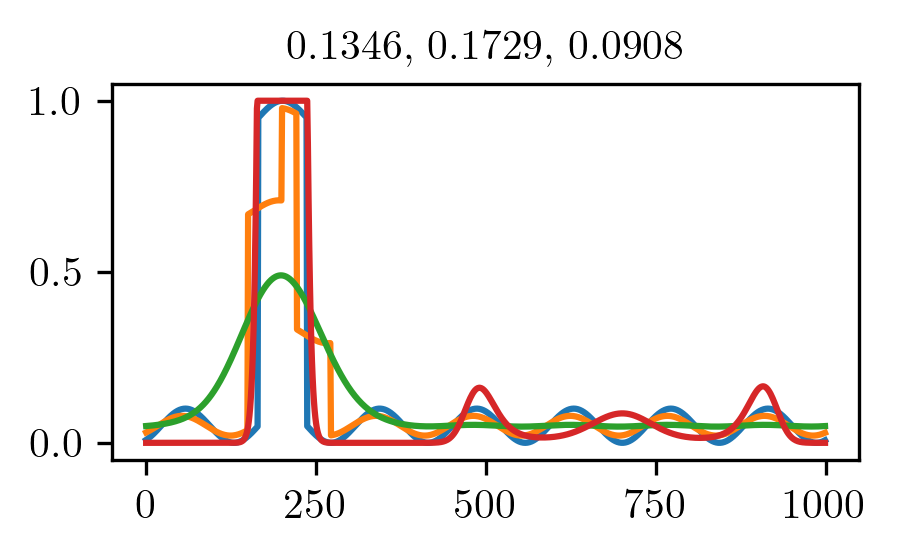

0.14458155144989715 0.17426240361763853 0.10747622229215617


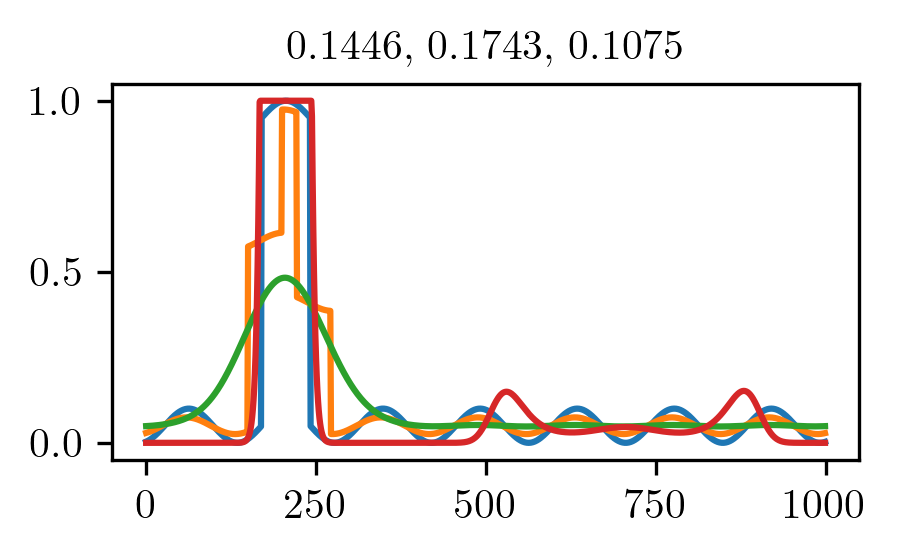

0.14779277577897992 0.1747371504887026 0.1233403653301818


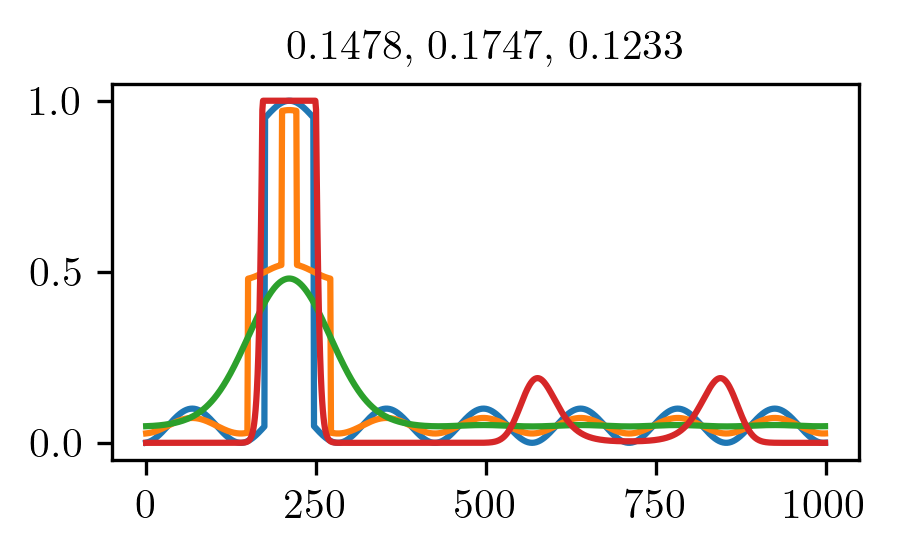

0.14458155144989712 0.17426240361763853 0.10747475554515756


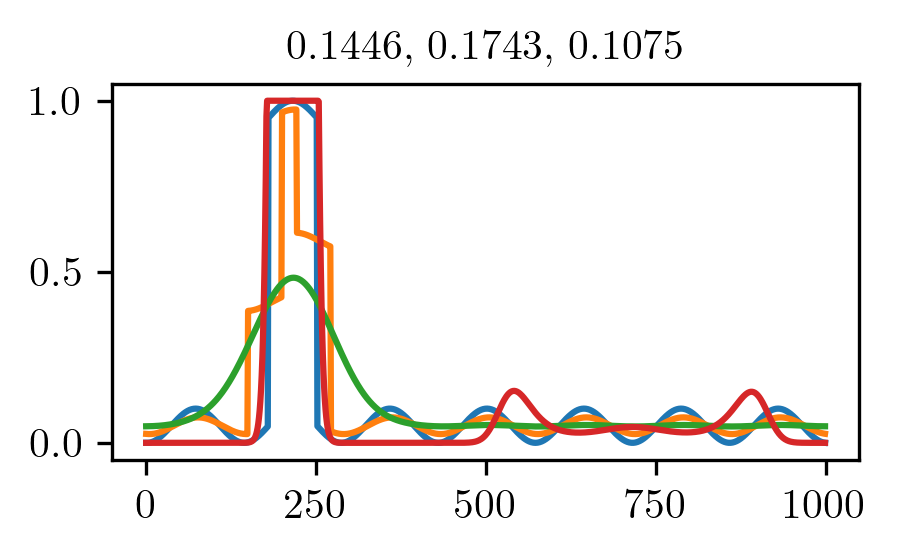

0.13461638691003935 0.17287561215445207 0.09081399408686823


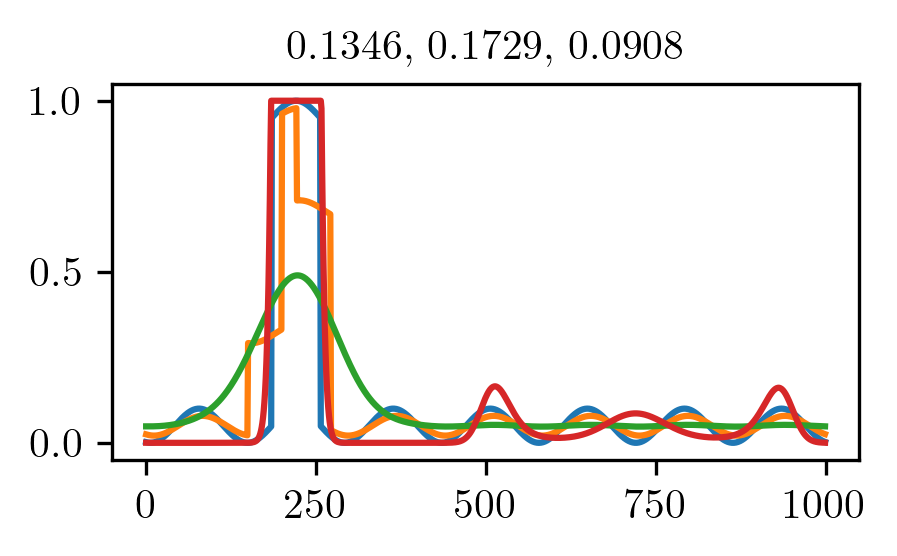

0.11660394649347224 0.1706894554849012 0.07208551800151922


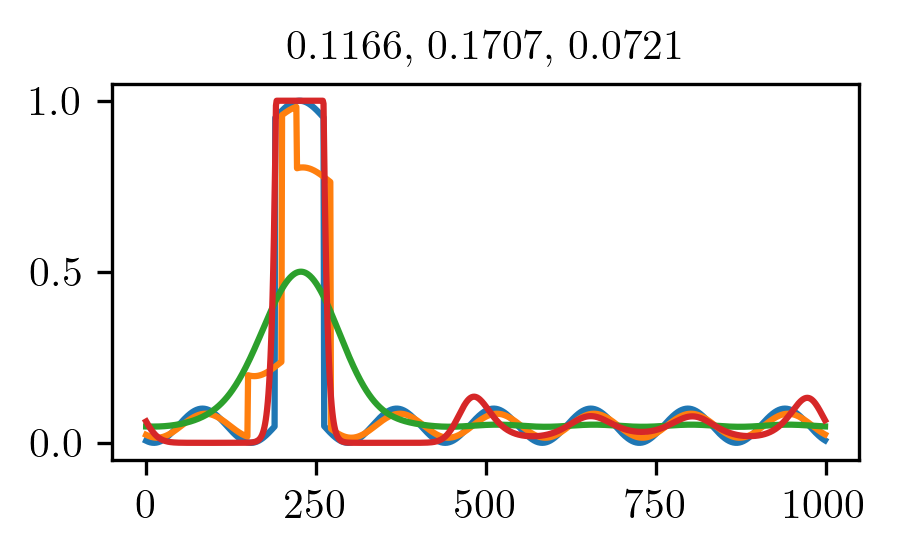

0.08653063549174127 0.16789247036111235 0.06427694037386182


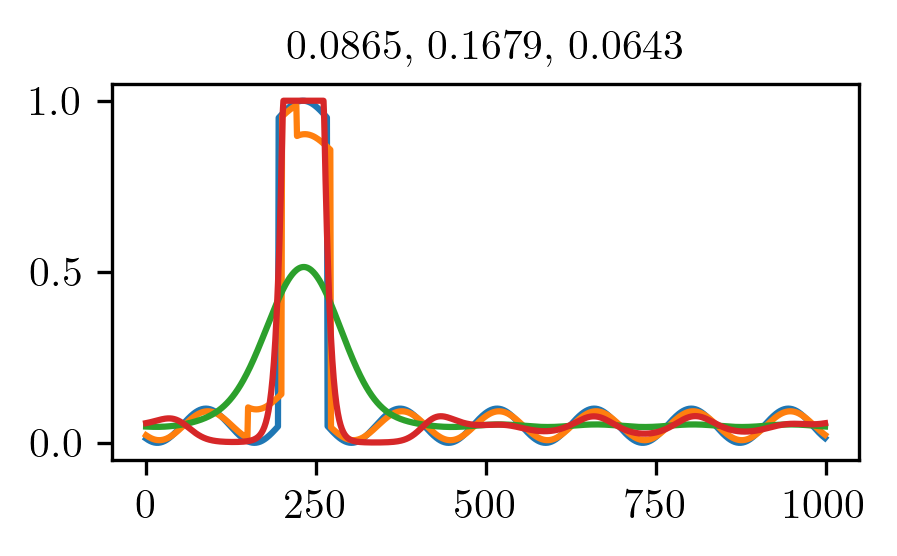

2.8056598319607945e-16 0.16474875287493726 0.07265228819254935


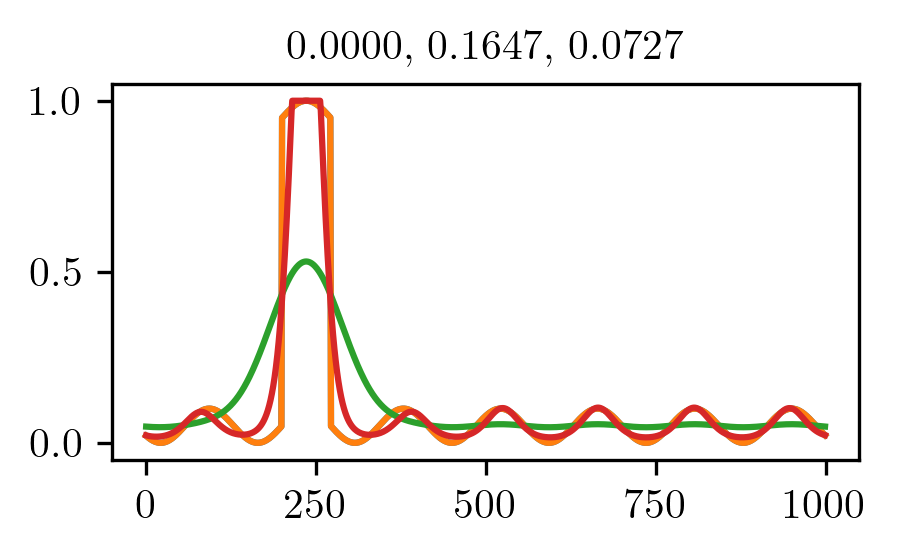

In [34]:
n = 21
rank = 21
shape = (m,)

_X_train = np.empty((m, n))
_mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]
for j, mu_j in enumerate(_mu_train):
    _X_train[:, j] = pulse(x, mu_j)

improvement, X_test_ROM, X_test_sROM, X_test_sROMs = zielfunktion([0.05, 2.0], x, _mu_train, _X_train, mu_test,
                                                                  X_test, rank, shape, num_iter2)

_X_train_s = smoothen(_X_train, sigma/dx, shape)

for j, mu_j in enumerate(mu_test):
    eR = np.mean((X_test_ROM[:, j]-X_test[:, j])**2)**.5
    esR = np.mean((X_test_sROM[:, j]-X_test[:, j])**2)**.5
    esRs = np.mean((X_test_sROMs[:, j]-X_test[:, j])**2)**.5
    print(eR, esR, esRs)
    plt.plot(X_test[:, j])
    plt.plot(X_test_ROM[:, j])
    plt.plot(X_test_sROM[:, j])
    plt.plot(X_test_sROMs[:, j])
    plt.title("{:.4f}, {:.4f}, {:.4f}".format(eR, esR, esRs))
    plt.show()

In [ ]:
asd

In [35]:
# increase n, error? improvement?
sigma_opt, c_opt = 0.05, 4
NN = np.arange(3, 100, 1)
sigma_opt = 0.9117*NN**(-1.305)
c_opt = 37.039*NN**(-0.93)
eROM = np.zeros_like(NN)
n_iter = 100
for i, n in enumerate(NN):
    rank = n

    # generate training data
    X_train = np.empty((m, n))
    mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]#
    for j, mu_j in enumerate(mu_train):
        X_train[:, j] = pulse(x, mu_j)
    
    # generate test data
    n1 = n//2
    n_test = 5
    mu_test = np.linspace(mu_train[n1, 0], mu_train[n1+1, 0], n_test, endpoint=False)[:, None]
    X_test = np.empty((m, n_test))
    for j, mu_j in enumerate(mu_test):
        X_test[:, j] = pulse(x, mu_j)
        
    # standard ROM
    standard_rom = train_ROM(mu_train, X_train, rank=rank)
    #X_test_ROM = standard_rom.predict(mu_test).T
    X_val_ROM = standard_rom.predict(mu_val).T
    eROM[i] = np.mean(L2_error(X_val_ROM, X_val))

    # optimize using test set
    #x0 = np.array([sigma, 2])
    x0 = np.array([sigma_opt[i], c_opt[i]])
    # n2 0.032075, 6.0601, 0.05107709, -70.3 %
    # 0.029052, 5.2371, 0.10354153, -39.7 %
    zf =  lambda x0: zielfunktion(x0, x, mu_train, X_train, mu_test, X_test, rank, shape, 100)[0]
    #res = minimize(zf, x0, method='nelder-mead', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='Powell', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='BFGS', options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 50})
    #res = minimize(zf, x0, method='COBYLA', bounds=[(0, 1), (-1, 10)], options={'disp': True, "rhobeg": np.array([.025, 0.5]), "maxiter": 50})
    res = minimize(zf, x0, method='SLSQP', bounds=[(0.001, 10*sigma_opt[i]), (-1, 10*c_opt[i])], options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 20, "ftol": 0.001})
    sigma_opt[i], c_opt[i] = res["x"]
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, n_iter)
#     for n_iter in [10, 20, 50, 100, 200, 500]:
#         print(n, n_iter, end=", ", sep=", ")
        
if False:
    # regularized ROM
    X_train_s = smoothen(X_train, sigma_opt/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    X_val_sROM = smooth_rom.predict(mu_val).T
    esROM = L2_error(X_val_sROM, X_val)
    
    # double checking: run target function again with optimal values
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter2)
    # de smoothing
    X_val_sROMs = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs = L2_error(X_val_sROMs, X_val)
    # de smoothing with a higher number of iterations
    X_val_sROMs2 = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2 = L2_error(X_val_sROMs2, X_val)

    print("$\|u_{rb}-u_h\|_{L_2}=$", np.mean(eROM), np.mean(eROM)/np.mean(eROM))
    print("$\|u_{rb,S}-u_h\|_{L_2}=$", np.mean(esROM), np.mean(esROM)/np.mean(eROM))
    print("$\|u_{rb, D_{10}}-u_h\|_{L_2}=$", np.mean(esROMs), np.mean(esROMs)/np.mean(eROM))
    print("$\|u_{rb, D_{100}}-u_h\|_{L_2}=$", np.mean(esROMs2), np.mean(esROMs2)/np.mean(eROM))

    # plot results
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
    plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
    plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
    plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$\mu$")
    plt.xlim(0, 1)
    plt.ylim(0, 0.4)
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()
    print(res)

<>:66: SyntaxWarning: invalid escape sequence '\|'
<>:67: SyntaxWarning: invalid escape sequence '\|'
<>:68: SyntaxWarning: invalid escape sequence '\|'
<>:69: SyntaxWarning: invalid escape sequence '\|'
<>:78: SyntaxWarning: invalid escape sequence '\|'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\|'
<>:67: SyntaxWarning: invalid escape sequence '\|'
<>:68: SyntaxWarning: invalid escape sequence '\|'
<>:69: SyntaxWarning: invalid escape sequence '\|'
<>:78: SyntaxWarning: invalid escape sequence '\|'
<>:79: SyntaxWarning: invalid escape sequence '\m'
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2775652854.py:66: SyntaxWarning: invalid escape sequence '\|'
  print("$\|u_{rb}-u_h\|_{L_2}=$", np.mean(eROM), np.mean(eROM)/np.mean(eROM))
C:\Users\florianma\AppData\Local\Temp\ipykernel_21684\2775652854.py:67: SyntaxWarning: invalid escape sequence '\|'
  print("$\|u_{rb,S}-u_h\|_{L_2}=$", np.mean(esROM), np.mean(esROM)/np.mean(e

AttributeError: 'Database' object has no attribute 'T'

In [ ]:
_i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter1)
print(L2_error(_sR, X_test))
print(L2_error(_sRs, X_test))

_sRs2 = post_process(x, X_test_sROM, sigma_opt, c_opt, mu_test, mu_train,
                            num_iter1, shape=shape, clip=clip)
for j in range(len(mu_test)):
    plt.plot(x, X_test[:, j])
    plt.plot(x, _sR[:, j])
    plt.plot(x, _sRs[:, j])
    plt.plot(x, _sRs2[:, j], "k--", lw=1)
    plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
plt.xlabel("$\mu$")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim(0.2, .25)
plt.ylim(0, 0.2)
plt.show()